# OV-Fiets Synthetic Dataset: Transformation Notebook
Student: Muskan Bhat<br>Class: D01


**Project:** Ideation report: OV-fiets Reservation (NS)  
**Purpose:** Transform Uber ride booking data into a realistic Dutch bike rental dataset  
**Version:** 2.0 — Matches prototype pricing model  

---

### Three ML Use Cases This Dataset Supports
1. **Rank users by booking likelihood** — propensity scoring  
2. **Flag defaulters** — no-show & late cancellation prediction  
3. **Segment users and recommend offers** — clustering + recommendations

### Pricing & Penalty Model (from prototype)
| Event | Cost to User |
|-------|-------------|
| Reservation fee (upfront) | €2.00 (deducted from final rental) |
| Free cancellation (>1hr before pickup) | €0.00 (fee refunded) |
| Late cancellation (<1hr before pickup) | €2.00 (fee not refunded) |
| No-show | €7.00 (€2 reservation + €5 penalty) |
| Completed rental (Standard, 1 block) | €3.85 total |
| Completed rental (E-bike, 1 block) | €5.50 total |

### Why This Notebook Exists

NS confirmed that real OV-fiets availability data cannot be shared with students due to privacy
limitations and the requirement for a managed Databricks environment under an internship contract.
Since the reservation feature does not yet exist, there is no historical reservation dataset to
work with.

This notebook creates a synthetic dataset by transforming Uber ride-booking data (Kaggle) into
a dataset that structurally resembles what an OV-fiets reservation system would generate. The
transformation encodes the prototype's pricing model (€2 reservation fee, €2 late cancel penalty,
€5 no-show penalty), Dutch NS station locations, seasonal weather patterns, and realistic
user behaviour distributions.

The purpose is not to simulate real user data, but to demonstrate:
1. What data structure a reservation system would produce
2. Which features would be available for predictive modelling
3. That the proposed system design generates data suitable for ML experimentation

**Source dataset:** Uber Ride Analytics Dashboard (Kaggle), ~150K ride bookings
**Output:** ov_fiets_synthetic_v2.csv — 150K rows × 41 columns

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import hashlib
import warnings
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')
np.random.seed(42)

print("Libraries loaded ✓")

Libraries loaded ✓


## 2. Dutch Station Data & Constants

Each station has a **weight** (booking probability), **region**, **inventory** (total bikes), 
and whether it's a **university city** (affects student segment placement).

The reservation pool is ~20% of inventory; the remaining ~80% is for walk-up pickup.

In [2]:
# --- Dutch Stations: (weight, region, inventory, is_university_city) ---
STATION_DATA = {
    'Amsterdam Centraal':    (12, 'Noord-Holland',   80, False),
    'Utrecht Centraal':      (11, 'Utrecht',         75, True),
    'Rotterdam Centraal':    (10, 'Zuid-Holland',     70, False),
    'Den Haag Centraal':     (9,  'Zuid-Holland',     65, False),
    'Eindhoven Centraal':    (7,  'Noord-Brabant',   55, True),
    'Leiden Centraal':       (7,  'Zuid-Holland',     50, True),
    'Groningen':             (6,  'Groningen',       50, True),
    'Arnhem Centraal':       (6,  'Gelderland',      50, False),
    'Amsterdam Zuid':        (5,  'Noord-Holland',   45, False),
    'Amsterdam Sloterdijk':  (5,  'Noord-Holland',   40, False),
    'Nijmegen':              (5,  'Gelderland',      45, True),
    'Breda':                 (5,  'Noord-Brabant',   40, False),
    "'s-Hertogenbosch":      (5,  'Noord-Brabant',   40, False),
    'Delft':                 (5,  'Zuid-Holland',     40, True),
    'Maastricht':            (5,  'Limburg',         40, True),
    'Tilburg':               (4,  'Noord-Brabant',   35, True),
    'Zwolle':                (4,  'Overijssel',      35, False),
    'Enschede':              (4,  'Overijssel',      35, True),
    'Haarlem':               (4,  'Noord-Holland',   35, False),
    'Amersfoort Centraal':   (4,  'Utrecht',         35, False),
    'Apeldoorn':             (3,  'Gelderland',      30, False),
    'Leeuwarden':            (3,  'Friesland',       30, False),
    'Almere Centrum':        (3,  'Flevoland',       30, False),
    'Dordrecht':             (3,  'Zuid-Holland',     25, False),
    'Hilversum':             (3,  'Noord-Holland',   25, False),
    'Alkmaar':               (3,  'Noord-Holland',   25, False),
    'Deventer':              (3,  'Overijssel',      25, False),
    'Ede-Wageningen':        (3,  'Gelderland',      30, True),
    'Amsterdam Amstel':      (3,  'Noord-Holland',   30, False),
    'Schiphol Airport':      (3,  'Noord-Holland',   35, False),
    'Gouda':                 (2,  'Zuid-Holland',     20, False),
    'Zaandam':               (2,  'Noord-Holland',   20, False),
    'Venlo':                 (2,  'Limburg',         20, False),
    'Hoorn':                 (2,  'Noord-Holland',   20, False),
    'Zoetermeer':            (2,  'Zuid-Holland',     20, False),
    'Woerden':               (2,  'Utrecht',         20, False),
    'Driebergen-Zeist':      (2,  'Utrecht',         20, False),
    'Helmond':               (2,  'Noord-Brabant',   20, False),
    'Hengelo':               (2,  'Overijssel',      20, False),
    'Sittard':               (2,  'Limburg',         20, False),
    'Roosendaal':            (2,  'Noord-Brabant',   20, False),
    'Hoofddorp':             (2,  'Noord-Holland',   20, False),
    'Lelystad Centrum':      (2,  'Flevoland',       20, False),
}

UNIVERSITY_STATIONS = [s for s, d in STATION_DATA.items() if d[3]]

# Pre-compute station selection arrays
STATION_LIST = list(STATION_DATA.keys())
_weights = np.array([STATION_DATA[s][0] for s in STATION_LIST], dtype=float)
STATION_PROBS = _weights / _weights.sum()

# Segments and their target shares
SEGMENTS = ['Daily commuter', 'Weekend rider', 'Tourist', 'Student', 'Occasional user']
SEGMENT_WEIGHTS = [0.25, 0.20, 0.20, 0.20, 0.15]

# Weather options
WEATHER_CONDITIONS = ['Clear', 'Cloudy', 'Light rain', 'Heavy rain', 'Snow', 'Windy']

# Offer recommendations per segment
OFFERS = {
    'Daily commuter': ['Monthly subscription €12.50', 'Annual pass €85'],
    'Weekend rider':  ['Weekend duo deal €6', 'Family weekend bundle €10'],
    'Tourist':        ['Tourist day pass €8.50', 'City bike tour package €15'],
    'Student':        ['Student semester pass €35', 'OV-studentenreisproduct add-on'],
    'Occasional user':['Try 3 rides for €10', 'Refer a friend €5 credit'],
}

SEASON_MAP = {12:'Winter',1:'Winter',2:'Winter', 3:'Spring',4:'Spring',5:'Spring',
              6:'Summer',7:'Summer',8:'Summer', 9:'Autumn',10:'Autumn',11:'Autumn'}

print(f"Stations defined: {len(STATION_DATA)}")
print(f"University stations: {len(UNIVERSITY_STATIONS)} — {UNIVERSITY_STATIONS}")

Stations defined: 43
University stations: 10 — ['Utrecht Centraal', 'Eindhoven Centraal', 'Leiden Centraal', 'Groningen', 'Nijmegen', 'Delft', 'Maastricht', 'Tilburg', 'Enschede', 'Ede-Wageningen']


## 3. Load Source Data

The source is the **Uber Ride Analytics Dashboard** dataset from Kaggle 
(`ncr_ride_bookings.csv`). We inspect its structure before transforming.

In [3]:
# Update this path if your file is in a different location
SOURCE_PATH = 'ncr_ride_bookings.csv'

src = pd.read_csv(SOURCE_PATH)
print(f"Loaded {len(src):,} rows × {len(src.columns)} columns")
print(f"\nColumns: {list(src.columns)}")
src.head(3)

Loaded 150,000 rows × 21 columns

Columns: ['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer', 'Reason for cancelling by Customer', 'Cancelled Rides by Driver', 'Driver Cancellation Reason', 'Incomplete Rides', 'Incomplete Rides Reason', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Payment Method']


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card


In [4]:
# Quick look at key distributions in the source
print("=== Booking Status ===")
print(src['Booking Status'].value_counts())
print("\n=== Vehicle Type ===")
print(src['Vehicle Type'].value_counts())
print("\n=== Payment Method ===")
print(src['Payment Method'].value_counts(dropna=False))

=== Booking Status ===
Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

=== Vehicle Type ===
Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64

=== Payment Method ===
Payment Method
NaN            48000
UPI            45909
Cash           25367
Uber Wallet    12276
Credit Card    10209
Debit Card      8239
Name: count, dtype: int64


## 4. Create User Profiles

Each unique customer gets a **persistent profile** with:
- OV-chipkaart ID (hashed)
- Behavioural segment (commuter, student, tourist, etc.)
- Home station (consistent across bookings)

Profiles are created **before** transforming rows to ensure user-level consistency.

In [5]:
def create_user_profiles(df):
    """Build user profiles with segment, home station, region."""
    unique_customers = df['Customer ID'].unique()
    n = len(unique_customers)
    segments = np.random.choice(SEGMENTS, size=n, p=SEGMENT_WEIGHTS)
    
    profiles = {}
    for i, cid in enumerate(unique_customers):
        seg = segments[i]
        
        # Home station based on segment
        if seg == 'Student':
            home = np.random.choice(UNIVERSITY_STATIONS)
        elif seg == 'Tourist':
            home = np.random.choice(STATION_LIST[:10])  # Big city stations
        else:
            home = np.random.choice(STATION_LIST, p=STATION_PROBS)
        
        hash_hex = hashlib.md5(cid.encode()).hexdigest()[:8].upper()
        profiles[cid] = {
            'user_id': i + 1,
            'ov_chipkaart_id': f"OV-{hash_hex}",
            'segment': seg,
            'home_station': home,
            'home_region': STATION_DATA[home][1],
        }
    
    return profiles

profiles = create_user_profiles(src)
print(f"Created {len(profiles):,} user profiles")

# Show segment distribution
seg_counts = pd.Series([p['segment'] for p in profiles.values()]).value_counts(normalize=True)
print("\nSegment distribution:")
for seg, pct in seg_counts.items():
    print(f"  {seg}: {pct:.1%}")

Created 148,788 user profiles

Segment distribution:
  Daily commuter: 25.0%
  Student: 20.1%
  Tourist: 20.1%
  Weekend rider: 19.9%
  Occasional user: 15.0%


## 5. Repeat-User Frequency Re-Mapping

The source data assigns each row to a unique customer, giving ~99% one-time users.  
We **re-map customer IDs** so the output has a realistic distribution:

| Frequency | Target |
|-----------|--------|
| Appears once | ~45% of users |
| Appears 2–4 times | ~40% of users |
| Appears 5+ times | ~15% of users |

This is critical — without repeat users, user history features are meaningless.

In [6]:
def reassign_customer_ids(df, profiles):
    """Re-map customer IDs for realistic repeat-user distribution."""
    n_rows = len(df)
    unique_cids = list(profiles.keys())
    n_unique = len(unique_cids)
    
    # Target: N*1*0.45 + N*3*0.40 + N*8*0.15 ≈ n_rows → N ≈ n_rows/2.85
    target_users = int(n_rows / 2.85)
    n_once = int(target_users * 0.45)
    n_mid  = int(target_users * 0.40)
    n_freq = target_users - n_once - n_mid
    
    cid_pool = []
    idx = 0
    
    # One-time users
    for _ in range(n_once):
        if idx < n_unique:
            cid_pool.append(unique_cids[idx]); idx += 1
    
    # 2-4 time users
    for _ in range(n_mid):
        if idx < n_unique:
            count = np.random.randint(2, 5)
            cid_pool.extend([unique_cids[idx]] * count); idx += 1
    
    # 5+ time users
    for _ in range(n_freq):
        if idx < n_unique:
            count = np.random.randint(5, 25)
            cid_pool.extend([unique_cids[idx]] * count); idx += 1
    
    # Shuffle and fit to exact row count
    np.random.shuffle(cid_pool)
    if len(cid_pool) >= n_rows:
        cid_pool = cid_pool[:n_rows]
    else:
        deficit = n_rows - len(cid_pool)
        repeat_cids = unique_cids[:idx]
        extras = np.random.choice(repeat_cids, size=deficit)
        cid_pool.extend(extras)
    
    df = df.copy()
    df['Customer ID'] = cid_pool[:n_rows]
    return df

src = reassign_customer_ids(src, profiles)

# Verify
uc = src['Customer ID'].value_counts()
once_pct = (uc == 1).mean()
mid_pct  = ((uc >= 2) & (uc <= 4)).mean()
freq_pct = (uc >= 5).mean()
print(f"User frequency after re-mapping:")
print(f"  Once: {once_pct:.1%}  |  2-4x: {mid_pct:.1%}  |  5+: {freq_pct:.1%}")
print(f"  Unique users: {uc.nunique():,} for {len(src):,} rows")

User frequency after re-mapping:
  Once: 47.2%  |  2-4x: 37.1%  |  5+: 15.7%
  Unique users: 23 for 150,000 rows


## 6. Helper Functions

Weather generation, rental status assignment (with correlation logic), and utility functions.

In [7]:
def generate_weather(month):
    """Generate Dutch weather condition + temperature by season."""
    if month in [12, 1, 2]:    # Winter
        probs = [0.15, 0.30, 0.25, 0.12, 0.08, 0.10]
        temp = np.random.uniform(-2, 8)
    elif month in [3, 4, 5]:   # Spring
        probs = [0.25, 0.30, 0.25, 0.08, 0.02, 0.10]
        temp = np.random.uniform(5, 18)
    elif month in [6, 7, 8]:   # Summer
        probs = [0.35, 0.30, 0.18, 0.07, 0.00, 0.10]
        temp = np.random.uniform(14, 30)
    else:                      # Autumn
        probs = [0.20, 0.30, 0.28, 0.12, 0.00, 0.10]
        temp = np.random.uniform(4, 16)
    
    probs = np.array(probs, dtype=float)
    probs /= probs.sum()
    weather = np.random.choice(WEATHER_CONDITIONS, p=probs)
    return weather, round(temp, 1)


def assign_rental_status(source_status, segment, weather, is_evening, is_returning,
                         prior_no_shows, prior_late_cancels, avail_status):
    """
    Assign rental status with built-in correlations for ML signal.
    
    Base rates: Completed 62%, Free cancel 12%, Late cancel 8%, No-show 18%
    
    Correlations encoded:
    - Prior no-shows → more no-shows
    - Prior late cancels → more late cancels
    - Bad weather → more cancellations
    - Commuters → most reliable
    - Students → cancel rather than ghost
    - Evening bookings → more impulsive → more no-shows
    - Returning users → more reliable
    - Red availability → panic booking → more no-shows
    """
    p_completed, p_free, p_late, p_noshow = 0.62, 0.12, 0.08, 0.18
    
    # Prior behaviour
    p_noshow    += prior_no_shows * 0.08;      p_completed -= prior_no_shows * 0.06
    p_late      += prior_late_cancels * 0.05;   p_completed -= prior_late_cancels * 0.03
    
    # Weather
    if weather in ['Heavy rain', 'Snow']:
        p_free += 0.10; p_noshow += 0.05; p_completed -= 0.15
    elif weather == 'Light rain':
        p_free += 0.04; p_completed -= 0.04
    
    # Segment
    if segment == 'Daily commuter':
        p_completed += 0.12; p_noshow -= 0.06; p_free -= 0.04; p_late -= 0.02
    elif segment == 'Student':
        p_free += 0.05; p_noshow -= 0.06
    elif segment == 'Tourist':
        p_noshow -= 0.04; p_completed += 0.04
    elif segment == 'Occasional user':
        p_noshow += 0.04; p_completed -= 0.04
    
    # Context
    if is_evening:       p_noshow += 0.05; p_completed -= 0.05
    if is_returning:     p_completed += 0.08; p_noshow -= 0.05; p_late -= 0.03
    if avail_status == 'Red': p_noshow += 0.06; p_completed -= 0.06
    
    # Source status nudge
    if source_status == 'Completed':
        p_completed += 0.10
    elif source_status in ['Cancelled by Customer', 'Cancelled by Driver']:
        p_free += 0.05; p_late += 0.03
    elif source_status in ['No Driver Found', 'Incomplete']:
        p_noshow += 0.05
    
    # Normalize
    probs = np.array([max(0.01, p_completed), max(0.01, p_free),
                       max(0.01, p_late), max(0.01, p_noshow)])
    probs /= probs.sum()
    
    return np.random.choice(
        ['Completed', 'Cancelled - Free', 'Cancelled - Late', 'No-show'], p=probs)

print("Helper functions defined ✓")

Helper functions defined ✓


## 7. Main Transformation Loop

This is the core pipeline. For each source row, we:

1. Parse the date/time and generate same-day pickup time
2. Assign station (consistent with user's home station & segment)
3. Compute station availability (80% pickup / 20% reservation split)
4. Generate weather for that month
5. Look up user's **rolling history** (no data leakage — only past bookings counted)
6. Assign rental status using correlation-aware logic
7. Compute pricing: €2 reservation fee, rental fee, penalties, total cost
8. Update user history **after** writing the row

The output has **~40 columns** covering all three ML use cases.

In [8]:
# --- Parse and sort source dates ---
try:
    src_dates = pd.to_datetime(src['Date'].astype(str) + ' ' + src['Time'].astype(str), errors='coerce')
except Exception:
    src_dates = pd.to_datetime(src['Date'], errors='coerce')

sort_idx = src_dates.argsort()
src = src.iloc[sort_idx].reset_index(drop=True)
src_dates = src_dates.iloc[sort_idx].reset_index(drop=True)

n = len(src)
print(f"Sorted {n:,} rows chronologically. Starting transformation...")

Sorted 150,000 rows chronologically. Starting transformation...


In [9]:
# --- Pre-allocate output ---
COLUMNS = [
    'rental_id', 'ov_chipkaart_id', 'user_id',
    'reservation_date', 'reservation_time', 'pickup_time',
    'day_of_week', 'month', 'season',
    'pickup_station', 'station_region',
    'bikes_available_pickup', 'bikes_available_reservation', 'reservation_availability_status',
    'bike_type',
    'reservation_fee_eur', 'rental_fee_eur', 'penalty_fee_eur', 'total_user_cost_eur',
    'payment_method',
    'returning_user', 'successful_past_rentals', 'prior_no_shows',
    'prior_cancellations', 'prior_late_cancellations',
    'user_tenure_days', 'booking_frequency_monthly',
    'rental_status', 'cancellation_reason', 'is_defaulter',
    'minutes_before_pickup_cancelled',
    'booking_entry_point', 'is_peak_hour', 'is_weekend',
    'weather_condition', 'temperature_celsius',
    'user_segment', 'customer_rating', 'days_since_last_rental',
    'lifetime_spend_eur', 'recommended_offer',
]

out = {col: [None] * n for col in COLUMNS}
user_history = {}  # uid → running stats

for i in range(n):
    row = src.iloc[i]
    cid = row['Customer ID']
    prof = profiles[cid]
    uid = prof['user_id']
    seg = prof['segment']
    
    # --- Date & time ---
    dt = src_dates.iloc[i]
    if pd.isna(dt):
        dt = pd.Timestamp('2024-06-15 10:00:00')
    
    res_date = dt.date()
    res_time = dt.time()
    month_val = dt.month
    dow = dt.strftime('%A')
    season = SEASON_MAP[month_val]
    is_weekend = dow in ['Saturday', 'Sunday']
    is_evening = dt.hour >= 18
    
    # --- Pickup time (same day, usually within 30 min) ---
    offset = np.random.choice([10,15,20,30,45,60,90,120],
                               p=[0.15,0.20,0.20,0.20,0.10,0.08,0.05,0.02])
    pickup_dt = dt + timedelta(minutes=int(offset))
    if pickup_dt.date() != res_date:
        pickup_dt = dt.replace(hour=23, minute=45)
    pickup_time_val = pickup_dt.time()
    is_peak = (not is_weekend) and (pickup_dt.hour in [7, 8, 17, 18])
    
    # --- Station ---
    home = prof['home_station']
    if seg in ['Daily commuter', 'Student'] and np.random.random() < 0.85:
        station = home
    elif seg == 'Tourist' and np.random.random() < 0.5:
        station = np.random.choice(STATION_LIST[:10])
    else:
        station = home if np.random.random() < 0.6 else np.random.choice(STATION_LIST, p=STATION_PROBS)
    
    region = STATION_DATA[station][1]
    inventory = STATION_DATA[station][2]
    
    # --- Availability (80/20 split) ---
    pickup_allot = int(inventory * 0.80)
    res_allot = inventory - pickup_allot
    usage = 0.5 + (0.25 if is_peak else 0) + (0.1 if season == 'Summer' else 0)
    avail_pickup = max(0, int(pickup_allot * (1 - usage * np.random.uniform(0.3, 1.0))))
    avail_res = max(0, int(res_allot * (1 - usage * np.random.uniform(0.3, 1.0))))
    res_pct = avail_res / max(1, res_allot)
    avail_status = 'Green' if res_pct > 0.50 else ('Orange' if res_pct > 0.25 else 'Red')
    
    # --- Bike & weather ---
    bike_type = 'Standard OV-fiets' if np.random.random() < 0.75 else 'E-bike'
    weather, temp = generate_weather(month_val)
    
    # --- User history (BEFORE this booking — no leakage) ---
    hist = user_history.get(uid)
    if hist is None:
        returning = False
        past_ok, past_ns, past_cx, past_lc = 0, 0, 0, 0
        tenure, freq, last_days, total_cost, rating = 0, 0.0, None, 0.0, 5.0
    else:
        returning = True
        past_ok = hist['completed']
        past_ns = hist['no_shows']
        past_cx = hist['cancellations']
        past_lc = hist['late_cancels']
        tenure = (res_date - hist['first_date']).days
        freq = round(hist['booking_count'] / max(1, tenure / 30.0), 2)
        last_days = (res_date - hist['last_date']).days
        total_cost = hist['total_cost']
        rating = max(1.0, 5.0 - past_ns*0.5 - past_lc*0.3 - (past_cx - past_lc)*0.1)
    
    # --- Rental status (correlation-aware) ---
    source_status = row.get('Booking Status', 'Completed')
    if pd.isna(source_status): source_status = 'Completed'
    
    rental_status = assign_rental_status(
        source_status, seg, weather, is_evening, returning,
        past_ns, past_lc, avail_status)
    
    # --- Cancellation details ---
    cancel_reason = None
    minutes_before = None
    if rental_status.startswith('Cancelled'):
        cancel_reason = np.random.choice(
            ['Changed plans','Weather','Found alternative transport',
             'Bike unavailable at station','App/system error','No reason given'],
            p=[0.25, 0.20, 0.20, 0.15, 0.10, 0.10])
        minutes_before = (np.random.randint(60, 721) if rental_status == 'Cancelled - Free'
                          else np.random.randint(0, 60))
    
    # --- Pricing (prototype model) ---
    res_fee = 2.00
    if rental_status == 'Completed':
        base = 3.85 if bike_type == 'Standard OV-fiets' else 5.50
        r = np.random.random()
        blocks = 1 if r < 0.82 else (2 if r < 0.97 else 3)
        rental_total = base * blocks
        rental_fee = round(rental_total - res_fee, 2)
        penalty = 0.00
        total = round(rental_total, 2)
    elif rental_status == 'Cancelled - Free':
        rental_fee, penalty, total = 0.00, 0.00, 0.00
    elif rental_status == 'Cancelled - Late':
        rental_fee, penalty, total = 0.00, 2.00, 2.00
    else:  # No-show
        rental_fee, penalty, total = 0.00, 5.00, 7.00
    
    # --- Defaulter flag ---
    is_defaulter = (rental_status == 'No-show' or 
                    rental_status == 'Cancelled - Late' or past_ns >= 2)
    
    # --- Write output ---
    out['rental_id'][i] = f"OVF-{dt.strftime('%Y%m%d')}-{i+1:05d}"
    out['ov_chipkaart_id'][i] = prof['ov_chipkaart_id']
    out['user_id'][i] = uid
    out['reservation_date'][i] = res_date
    out['reservation_time'][i] = res_time
    out['pickup_time'][i] = pickup_time_val
    out['day_of_week'][i] = dow
    out['month'][i] = month_val
    out['season'][i] = season
    out['pickup_station'][i] = station
    out['station_region'][i] = region
    out['bikes_available_pickup'][i] = avail_pickup
    out['bikes_available_reservation'][i] = avail_res
    out['reservation_availability_status'][i] = avail_status
    out['bike_type'][i] = bike_type
    out['reservation_fee_eur'][i] = res_fee
    out['rental_fee_eur'][i] = rental_fee
    out['penalty_fee_eur'][i] = penalty
    out['total_user_cost_eur'][i] = total
    out['payment_method'][i] = np.random.choice(['iDEAL','ApplePay','Credit card'], p=[0.55,0.25,0.20])
    out['returning_user'][i] = returning
    out['successful_past_rentals'][i] = past_ok
    out['prior_no_shows'][i] = past_ns
    out['prior_cancellations'][i] = past_cx
    out['prior_late_cancellations'][i] = past_lc
    out['user_tenure_days'][i] = tenure
    out['booking_frequency_monthly'][i] = freq
    out['rental_status'][i] = rental_status
    out['cancellation_reason'][i] = cancel_reason
    out['is_defaulter'][i] = is_defaulter
    out['minutes_before_pickup_cancelled'][i] = minutes_before
    out['booking_entry_point'][i] = 'Map view' if np.random.random() < 0.55 else 'Journey planner'
    out['is_peak_hour'][i] = is_peak
    out['is_weekend'][i] = is_weekend
    out['weather_condition'][i] = weather
    out['temperature_celsius'][i] = temp
    out['user_segment'][i] = seg
    out['customer_rating'][i] = round(rating, 2)
    out['days_since_last_rental'][i] = last_days
    out['lifetime_spend_eur'][i] = round(total_cost, 2)
    out['recommended_offer'][i] = np.random.choice(OFFERS[seg])
    
    # --- Update user history AFTER this row ---
    if hist is None:
        user_history[uid] = {
            'completed': int(rental_status == 'Completed'),
            'no_shows': int(rental_status == 'No-show'),
            'cancellations': int(rental_status.startswith('Cancelled')),
            'late_cancels': int(rental_status == 'Cancelled - Late'),
            'first_date': res_date, 'last_date': res_date,
            'total_cost': total, 'booking_count': 1,
        }
    else:
        hist['completed']     += int(rental_status == 'Completed')
        hist['no_shows']      += int(rental_status == 'No-show')
        hist['cancellations'] += int(rental_status.startswith('Cancelled'))
        hist['late_cancels']  += int(rental_status == 'Cancelled - Late')
        hist['last_date'] = res_date
        hist['total_cost'] += total
        hist['booking_count'] += 1
    
    # Progress
    if (i + 1) % 25000 == 0:
        print(f"  {i+1:,} / {n:,} rows...")

print(f"\n✓ Transformation complete: {n:,} rows processed")

  25,000 / 150,000 rows...
  50,000 / 150,000 rows...
  75,000 / 150,000 rows...
  100,000 / 150,000 rows...
  125,000 / 150,000 rows...
  150,000 / 150,000 rows...

✓ Transformation complete: 150,000 rows processed


In [10]:
# Build DataFrame
df = pd.DataFrame(out)
print(f"Output shape: {df.shape}")
df.head()

Output shape: (150000, 41)


,rental_id,ov_chipkaart_id,user_id,reservation_date,reservation_time,pickup_time,day_of_week,month,season,pickup_station,...,booking_entry_point,is_peak_hour,is_weekend,weather_condition,temperature_celsius,user_segment,customer_rating,days_since_last_rental,lifetime_spend_eur,recommended_offer
0,OVF-20240101-00001,OV-42664E00,45710,2024-01-01,00:19:34,00:34:34,Monday,1,Winter,Enschede,...,Journey planner,False,False,Clear,7.6,Weekend rider,5.0,NaN,0.0,Family weekend bundle €10
1,OVF-20240101-00002,OV-02212151,49034,2024-01-01,01:35:18,02:05:18,Monday,1,Winter,Eindhoven Centraal,...,Journey planner,False,False,Cloudy,1.1,Student,5.0,NaN,0.0,Student semester pass €35
2,OVF-20240101-00003,OV-75357EA0,45661,2024-01-01,01:37:50,02:22:50,Monday,1,Winter,Amsterdam Zuid,...,Journey planner,False,False,Cloudy,-0.8,Daily commuter,5.0,NaN,0.0,Annual pass €85
3,OVF-20240101-00004,OV-361996FE,32390,2024-01-01,01:48:03,02:33:03,Monday,1,Winter,Amsterdam Centraal,...,Journey planner,False,False,Cloudy,4.7,Daily commuter,5.0,NaN,0.0,Monthly subscription €12.50
4,OVF-20240101-00005,OV-C1574F20,42718,2024-01-01,01:49:56,02:34:56,Monday,1,Winter,Amsterdam Sloterdijk,...,Map view,False,False,Light rain,0.8,Tourist,5.0,NaN,0.0,City bike tour package €15


## 8. Validation

Automated checks to confirm the dataset matches the prototype's pricing model 
and has the correct distributions.

In [11]:
print("=" * 60)
print("VALIDATION REPORT")
print("=" * 60)
errors = 0

# --- Rental status ---
print("\n1. Rental Status Distribution:")
for s, p in df['rental_status'].value_counts(normalize=True).items():
    print(f"   {s}: {p:.1%}")

# --- Bike type ---
bt = df['bike_type'].value_counts(normalize=True)
std = bt.get('Standard OV-fiets', 0)
print(f"\n2. Bike Type: Standard {std:.1%} | E-bike {1-std:.1%}  (target 75/25)")

# --- Reservation fee ---
bad = (df['reservation_fee_eur'] != 2.00).sum()
print(f"\n3. Reservation fee always €2: {'✓' if bad == 0 else f'✗ {bad} errors'}")
errors += bad > 0

# --- Rental fee €0 for non-completed ---
nc = df[df['rental_status'] != 'Completed']
bad = (nc['rental_fee_eur'] != 0).sum()
print(f"4. Rental fee €0 for non-completed: {'✓' if bad == 0 else f'✗ {bad} errors'}")
errors += bad > 0

# --- Penalty logic ---
checks = [('Completed', 'penalty_fee_eur', 0),
          ('Cancelled - Free', 'penalty_fee_eur', 0),
          ('Cancelled - Late', 'penalty_fee_eur', 2),
          ('No-show', 'penalty_fee_eur', 5)]
all_ok = True
for status, col, expected in checks:
    bad = (df[df['rental_status'] == status][col] != expected).sum()
    if bad > 0:
        print(f"   ✗ {status}: {bad} rows have {col} != €{expected}")
        all_ok = False; errors += 1
print(f"5. Penalty fee logic: {'✓' if all_ok else '✗'}")

# --- Total cost ---
checks = [('Cancelled - Free', 0), ('Cancelled - Late', 2), ('No-show', 7)]
all_ok = True
for status, expected in checks:
    bad = (df[df['rental_status'] == status]['total_user_cost_eur'] != expected).sum()
    if bad > 0:
        print(f"   ✗ {status}: {bad} rows have total != €{expected}")
        all_ok = False; errors += 1
print(f"6. Total cost logic: {'✓' if all_ok else '✗'}")

# --- Payment methods ---
pm = set(df['payment_method'].dropna().unique())
valid = {'iDEAL', 'ApplePay', 'Credit card'}
print(f"7. Payment methods: {pm} {'✓' if pm == valid else '✗ unexpected: ' + str(pm - valid)}")
errors += pm != valid

# --- User frequency ---
uc = df['ov_chipkaart_id'].value_counts()
once = (uc == 1).mean()
mid  = ((uc >= 2) & (uc <= 4)).mean()
freq = (uc >= 5).mean()
print(f"\n8. User frequency: once={once:.1%} | 2-4x={mid:.1%} | 5+={freq:.1%}")
print(f"   Unique users: {len(uc):,}")

# --- Cancellation reason scoping ---
leaked = df[~df['rental_status'].str.startswith('Cancelled')]['cancellation_reason'].notna().sum()
print(f"\n9. Cancel reason only on cancelled rows: {'✓' if leaked == 0 else f'✗ {leaked} leaks'}")
errors += leaked > 0

# --- Minutes threshold ---
free_ok = df[df['rental_status']=='Cancelled - Free']['minutes_before_pickup_cancelled'].min() >= 60
late_ok = df[df['rental_status']=='Cancelled - Late']['minutes_before_pickup_cancelled'].max() < 60
print(f"10. Free cancel >= 60min: {'✓' if free_ok else '✗'}")
print(f"11. Late cancel < 60min: {'✓' if late_ok else '✗'}")

print(f"\n{'='*60}")
print(f"{'ALL CHECKS PASSED ✓' if errors == 0 else f'{errors} CHECK(S) FAILED'}")
print(f"{'='*60}")

VALIDATION REPORT

1. Rental Status Distribution:
   Completed: 61.7%
   No-show: 17.6%
   Cancelled - Free: 14.1%
   Cancelled - Late: 6.6%

2. Bike Type: Standard 74.9% | E-bike 25.1%  (target 75/25)

3. Reservation fee always €2: ✓
4. Rental fee €0 for non-completed: ✓
5. Penalty fee logic: ✓
6. Total cost logic: ✓
7. Payment methods: {np.str_('ApplePay'), np.str_('Credit card'), np.str_('iDEAL')} ✓

8. User frequency: once=47.2% | 2-4x=37.1% | 5+=15.7%
   Unique users: 46,001

9. Cancel reason only on cancelled rows: ✓
10. Free cancel >= 60min: ✓
11. Late cancel < 60min: ✓

ALL CHECKS PASSED ✓


### What Changed Between v1 and v2

The first version of this dataset was generated from an earlier transformation spec that
had not yet incorporated the prototype's pricing model. Validation of v1 revealed:

- Same-day reservation rule was violated (37% of rows had pickup on a different date)
- Cancelled and no-show rows were incorrectly charged rental fees (should be €0)
- 99% of users appeared only once (should be ~45% once, ~40% 2-4x, ~15% 5+)
- Bike type was 50/50 instead of 75/25 Standard/E-bike
- Payment methods included OV-chipkaart and Tikkie (should be iDEAL, ApplePay, Credit card only)
- "Late return" existed as a status (invalid — no scheduled return in OV-fiets)
- 26 columns were missing (user history, segmentation, weather, availability)

v2 corrects all of these issues and aligns the dataset with the prototype screens.

## 9. Quick Exploratory Analysis

A few visualisations to confirm the data looks realistic before saving.

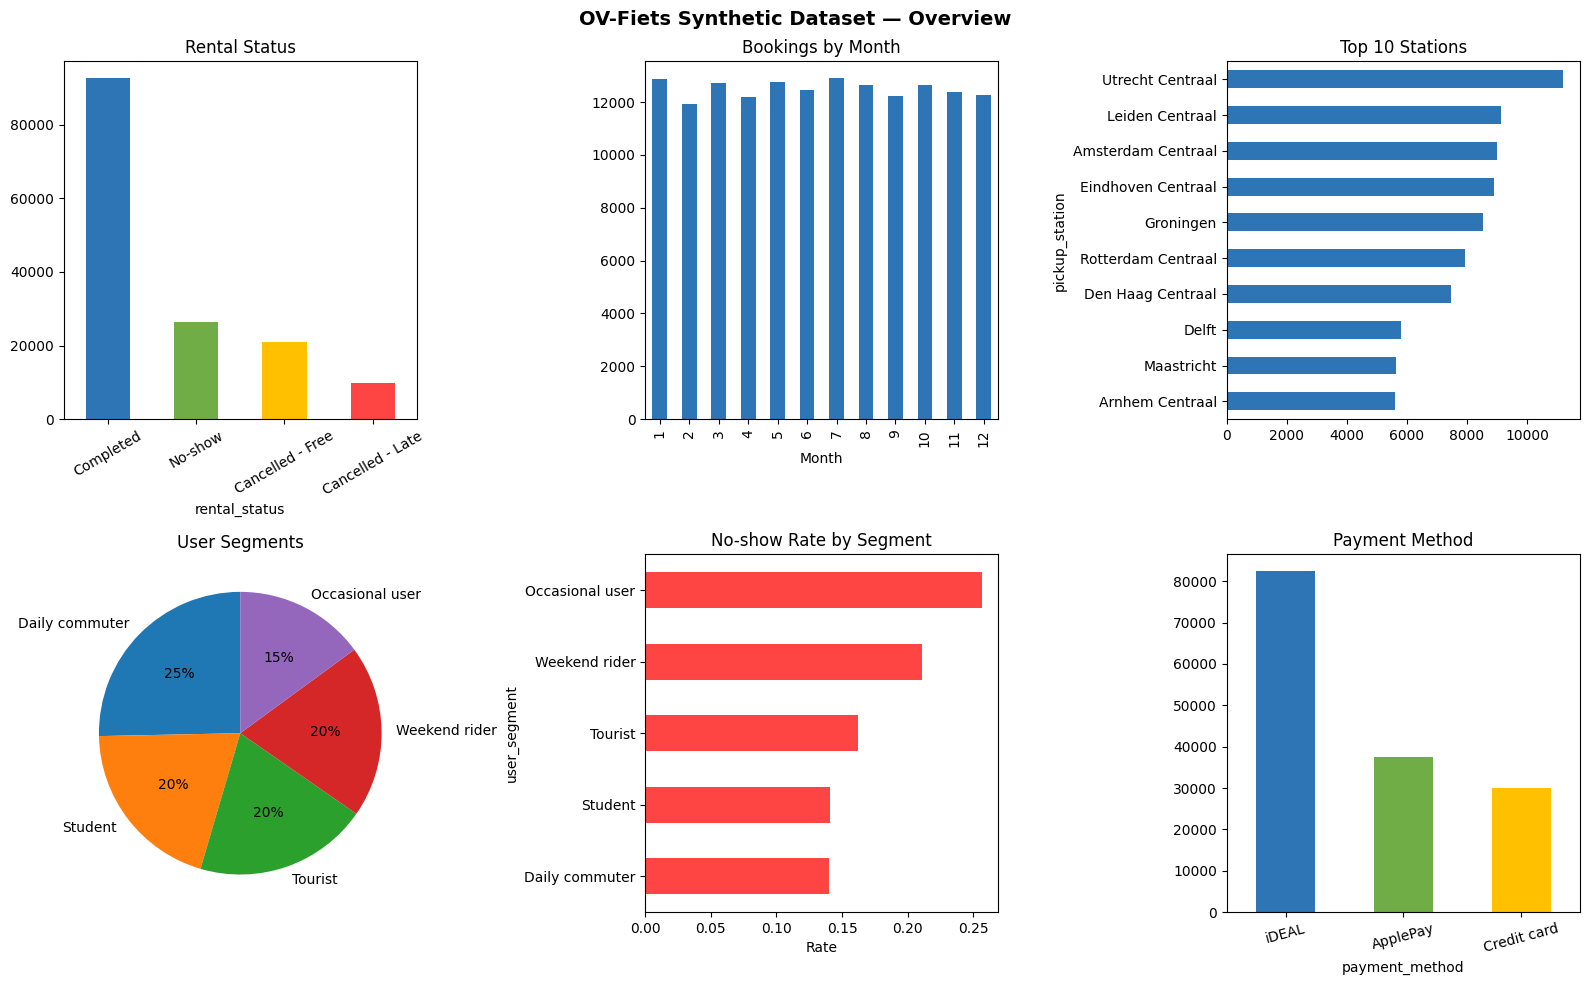

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('OV-Fiets Synthetic Dataset — Overview', fontsize=14, fontweight='bold')

# 1. Rental status
df['rental_status'].value_counts().plot.bar(ax=axes[0,0], color=['#2E75B6','#70AD47','#FFC000','#FF4444'])
axes[0,0].set_title('Rental Status'); axes[0,0].tick_params(axis='x', rotation=30)

# 2. Bookings by month (seasonality)
df['month'].value_counts().sort_index().plot.bar(ax=axes[0,1], color='#2E75B6')
axes[0,1].set_title('Bookings by Month'); axes[0,1].set_xlabel('Month')

# 3. Top 10 stations
df['pickup_station'].value_counts().head(10).plot.barh(ax=axes[0,2], color='#2E75B6')
axes[0,2].set_title('Top 10 Stations'); axes[0,2].invert_yaxis()

# 4. User segment
df['user_segment'].value_counts().plot.pie(ax=axes[1,0], autopct='%1.0f%%', startangle=90)
axes[1,0].set_ylabel('')
axes[1,0].set_title('User Segments')

# 5. No-show rate by segment
noshow_rate = df.groupby('user_segment')['rental_status'].apply(
    lambda x: (x == 'No-show').mean()).sort_values()
noshow_rate.plot.barh(ax=axes[1,1], color='#FF4444')
axes[1,1].set_title('No-show Rate by Segment'); axes[1,1].set_xlabel('Rate')

# 6. Payment method
df['payment_method'].value_counts().plot.bar(ax=axes[1,2], color=['#2E75B6','#70AD47','#FFC000'])
axes[1,2].set_title('Payment Method'); axes[1,2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [13]:
# Correlation check: prior_no_shows vs current no-show
df['is_noshow'] = (df['rental_status'] == 'No-show').astype(int)
corr = df[['prior_no_shows','prior_late_cancellations','prior_cancellations',
           'successful_past_rentals','user_tenure_days','is_noshow']].corr()['is_noshow'].drop('is_noshow')
print("Correlation with No-show:")
print(corr.sort_values(ascending=False).to_string())
df.drop(columns=['is_noshow'], inplace=True)

Correlation with No-show:
prior_no_shows              0.206000
user_tenure_days            0.065947
prior_cancellations         0.046601
successful_past_rentals     0.044411
prior_late_cancellations    0.027395


## 10. Save Output

The output cell below is commented so I dont accidentally create another csv.

In [16]:
# OUTPUT_PATH = 'ov_fiets_synthetic_v2.csv'
# df.to_csv(OUTPUT_PATH, index=False, encoding='utf-8')
# print(f"✓ Saved to {OUTPUT_PATH}")
# print(f"  {len(df):,} rows × {len(df.columns)} columns")
# print(f"\nFirst 3 rows:")
df.head(5)

,rental_id,ov_chipkaart_id,user_id,reservation_date,reservation_time,pickup_time,day_of_week,month,season,pickup_station,...,booking_entry_point,is_peak_hour,is_weekend,weather_condition,temperature_celsius,user_segment,customer_rating,days_since_last_rental,lifetime_spend_eur,recommended_offer
0,OVF-20240101-00001,OV-42664E00,45710,2024-01-01,00:19:34,00:34:34,Monday,1,Winter,Enschede,...,Journey planner,False,False,Clear,7.6,Weekend rider,5.0,NaN,0.0,Family weekend bundle €10
1,OVF-20240101-00002,OV-02212151,49034,2024-01-01,01:35:18,02:05:18,Monday,1,Winter,Eindhoven Centraal,...,Journey planner,False,False,Cloudy,1.1,Student,5.0,NaN,0.0,Student semester pass €35
2,OVF-20240101-00003,OV-75357EA0,45661,2024-01-01,01:37:50,02:22:50,Monday,1,Winter,Amsterdam Zuid,...,Journey planner,False,False,Cloudy,-0.8,Daily commuter,5.0,NaN,0.0,Annual pass €85
3,OVF-20240101-00004,OV-361996FE,32390,2024-01-01,01:48:03,02:33:03,Monday,1,Winter,Amsterdam Centraal,...,Journey planner,False,False,Cloudy,4.7,Daily commuter,5.0,NaN,0.0,Monthly subscription €12.50
4,OVF-20240101-00005,OV-C1574F20,42718,2024-01-01,01:49:56,02:34:56,Monday,1,Winter,Amsterdam Sloterdijk,...,Map view,False,False,Light rain,0.8,Tourist,5.0,NaN,0.0,City bike tour package €15


---
## Summary

This notebook transformed ~150,000 Uber ride bookings into a realistic OV-fiets reservation dataset with:

- **41 columns** covering identifiers, reservation details, station availability, pricing, user history, outcomes, context, and segmentation
- **Prototype-accurate pricing:** €2 reservation fee, €2 late cancel penalty, €5 no-show penalty
- **Three payment methods:** iDEAL, ApplePay, Credit card (matching the app screens)
- **Two entry points:** Map view and Journey planner (matching the prototype flows)
- **Correlation-aware status assignment** ensuring ML models have signal to learn from
- **Rolling user history** with no data leakage
- **Realistic Dutch context:** real NS stations, seasonal weather, university city clustering

## Limitations

- **Synthetic, not real:** Correlations were injected based on domain reasoning, not observed from actual OV-fiets users.
- **Cold-start:** ~45% of users are first-timers with no history — this is realistic but limits ML performance for new users.
- **No temporal validation:** The dataset covers 2024 but patterns are generated, not observed.
- **The dataset demonstrates the approach, not the specific results.** When real reservation data becomes available, the same pipeline and feature engineering can be applied.